In [1]:
# Task 3 – COVID-19 Data Analysis Report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("covid_19_clean_complete.csv")
df.head()


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


Basic Cleaning

In [ ]:
# Convert date column
df['Date'] = pd.to_datetime(df['Date'])
# Handle missing values
df = df.fillna(0)


Global Daily Trends

In [5]:
daily = df.groupby("Date")[["Confirmed","Recovered","Deaths"]].sum()
daily.head()


,Confirmed,Recovered,Deaths
Date,,,
2020-01-22,555,28,17
2020-01-23,654,30,18
2020-01-24,941,36,26
2020-01-25,1434,39,42
2020-01-26,2118,52,56


Plot Daily Cases (Line Chart)

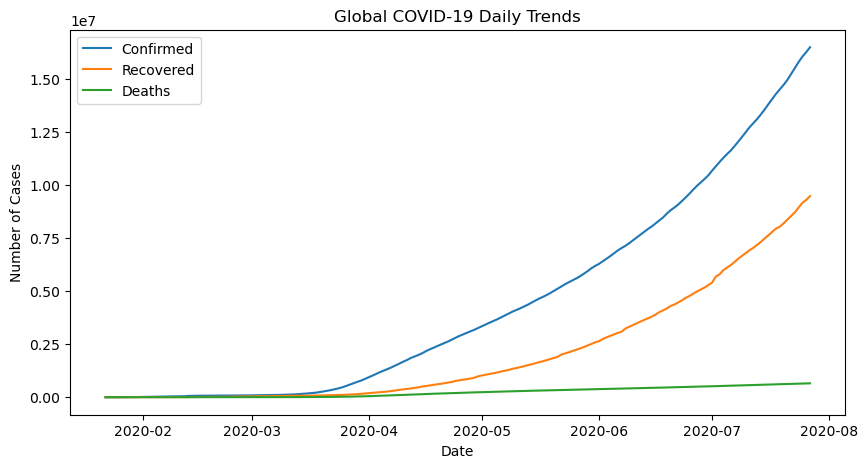

In [6]:
plt.figure(figsize=(10,5))
plt.plot(daily.index, daily["Confirmed"], label="Confirmed")
plt.plot(daily.index, daily["Recovered"], label="Recovered")
plt.plot(daily.index, daily["Deaths"], label="Deaths")
plt.title("Global COVID-19 Daily Trends")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()


Bar Chart (Daily New Cases)

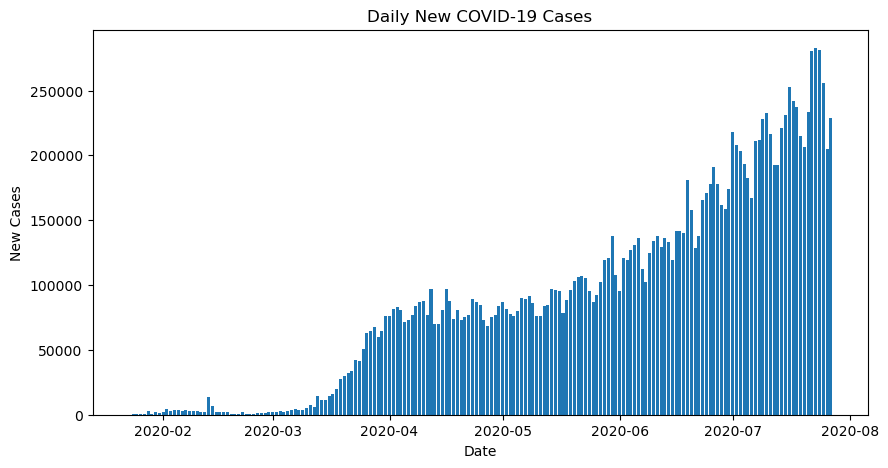

In [7]:
daily["New Cases"] = daily["Confirmed"].diff()

plt.figure(figsize=(10,5))
plt.bar(daily.index, daily["New Cases"])
plt.title("Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()


Trend Line (Overall Case Progression)

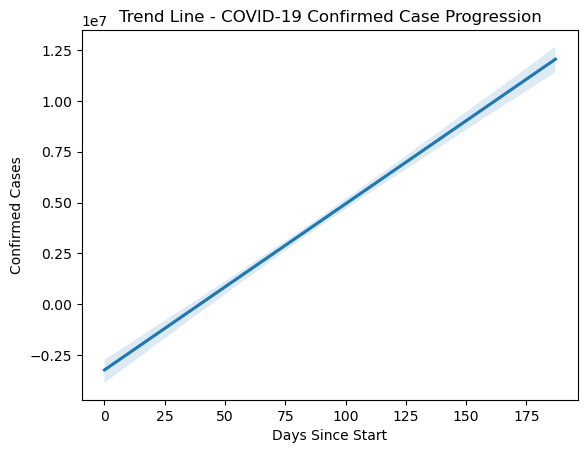

In [8]:
sns.regplot(x=daily.index.factorize()[0], y=daily["Confirmed"], scatter=False)
plt.title("Trend Line - COVID-19 Confirmed Case Progression")
plt.xlabel("Days Since Start")
plt.ylabel("Confirmed Cases")
plt.show()


Filter by Country

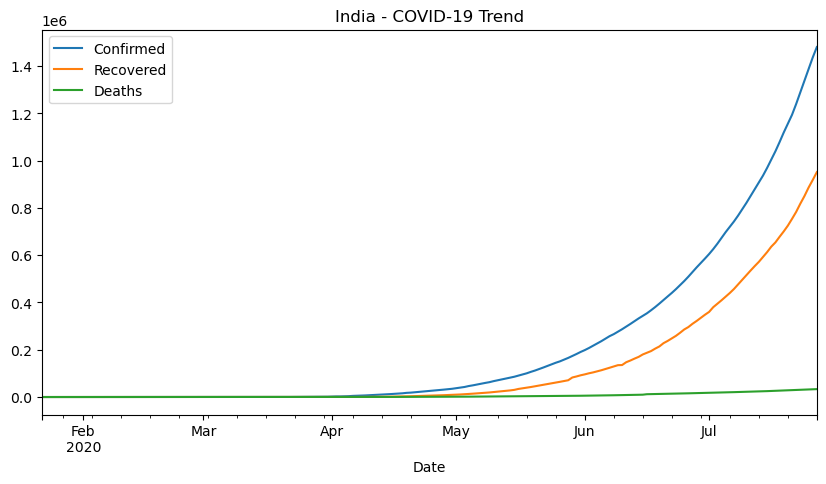

In [9]:
country = "India"   # change country name
country_df = df[df["Country/Region"] == country]

country_daily = country_df.groupby("Date")[["Confirmed","Recovered","Deaths"]].sum()

country_daily.plot(figsize=(10,5))
plt.title(f"{country} - COVID-19 Trend")
plt.show()


Simple Dashboard (Plotly)

In [10]:
!pip install plotly


In [11]:
import plotly.express as px

fig = px.line(daily, x=daily.index, y=["Confirmed","Recovered","Deaths"], title="COVID-19 Global Trend")
fig.show()


Insights

- COVID-19 cases increased rapidly worldwide from early 2020.
- Confirmed cases show exponential growth in the initial phase.
- Deaths follow a lagging trend compared to confirmed cases.
- Recovery rates improved in later stages.
- Trend line shows a clear upward trajectory of total infections.
- Country-level analysis shows different peaks depending on region.
